### Nama Anggota Kelompok:

1. Gaitsa Nazwa Kansa (24083010014)
2. Auliya Khotimatuz Zahroh (24083010061)
3. Carissa Naura Rajwa (24083010063)

# CRYPTOCURRENCY

Cryptocurrency adalah aset digital atau mata uang virtual yang menggunakan teknologi kriptografi untuk mengamankan transaksi dan beroperasi di atas sistem terdesentralisasi yang disebut blockchain. Berbeda dengan mata uang konvensional yang dikendalikan oleh bank atau pemerintah, cryptocurrency tidak memiliki otoritas pusat sehingga transaksi dilakukan secara langsung antar pengguna (peer-to-peer). Setiap transaksi dicatat dalam blockchain yang bersifat transparan, tidak dapat diubah, dan tersebar di banyak komputer. Contoh cryptocurrency yang populer antara lain Bitcoin, Ethereum, Solana, Dogecoin, dan Binance Coin, yang masing-masing memiliki karakteristik, fungsi, dan tingkat volatilitas yang berbeda di pasar.

## Mengambil Data dari 5 Jenis Crypto Menggunakan API

In [ ]:
import requests
import pandas as pd
import time
from google.colab import files

# 1. Konfigurasi
API_KEY = "CG-J9iaoDCtvaatKnBUiESrxy9n"
coins = ['bitcoin', 'ethereum', 'solana', 'dogecoin', 'binancecoin']
all_raw_data = []

headers = {"accept": "application/json", "x-cg-demo-api-key": API_KEY}

print("Sedang mengambil DATA MENTAH... Mohon tunggu.")

for coin in coins:
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {'vs_currency': 'usd', 'days': '90', 'interval': 'hourly'}

    response = requests.get(url, params=params, headers=headers)
    data = response.json()

    # 2. Ambil list murni dari API
    df_p = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
    df_c = pd.DataFrame(data['market_caps'], columns=['timestamp', 'market_cap'])
    df_v = pd.DataFrame(data['total_volumes'], columns=['timestamp', 'volume'])

    # 3. Gabungkan secara murni
    df_coin = df_p.merge(df_c, on='timestamp').merge(df_v, on='timestamp')
    df_coin['coin_name'] = coin

    all_raw_data.append(df_coin)
    time.sleep(2)
    print(f"Data mentah {coin} berhasil ditarik.")

# 4. Gabungkan semua koin
df_raw_final = pd.concat(all_raw_data, ignore_index=True)

# 6. Simpan dan Download
filename = 'crypto_raw_data_90days.csv'
df_raw_final.to_csv(filename, index=False)
files.download(filename)

print(f"\nSelesai! File {filename} berhasil diunduh.")
print(df_raw_final.sample(10)) # Intip 10 data acak
print(f"\nTotal baris data: {len(df_raw_final)}")

Sedang mengambil DATA MENTAH... Mohon tunggu.
Data mentah bitcoin berhasil ditarik.
Data mentah ethereum berhasil ditarik.
Data mentah solana berhasil ditarik.
Data mentah dogecoin berhasil ditarik.
Data mentah binancecoin berhasil ditarik.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Selesai! File crypto_raw_data_90days.csv berhasil diunduh.
          timestamp         price    market_cap        volume    coin_name
9608  1771833718380    599.108562  8.170895e+10  1.021916e+09  binancecoin
4238  1775918019861   2242.667767  2.707445e+11  1.107276e+10     ethereum
9237  1770498185845    652.864886  8.890111e+10  1.715710e+09  binancecoin
9541  1771592462276    609.073507  8.304858e+10  9.140401e+08  binancecoin
3557  1773464491586   2090.532142  2.523072e+11  2.415792e+10     ethereum
7207  1771002018230      0.096494  1.628349e+10  9.075493e+08     dogecoin
7102  1770624118664      0.095297  1.606737e+10  9.224626e+08     dogecoin
1949  1775480630026  69352.927351  1.387992e+12  3.741588e+10      bitcoin
5601  1773018233854     82.406431  4.702778e+10  2.799955e+09       solana
8869  1769173374713    886.070819  1.208827e+11  1.204973e+09  binancecoin

Total baris data: 10839


## Cleaning (missing value, duplikasi)


In [ ]:
df_raw_final.isnull().sum()

,0
timestamp,0
price,0
market_cap,0
volume,0
coin_name,0


In [ ]:
# Cek jumlah baris yang duplikat (berdasarkan timestamp dan nama koin)
duplicate_count = df_raw_final.duplicated(subset=['timestamp', 'coin_name']).sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


In [ ]:
df = df_raw_final.copy()

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

df = df.sort_values(['coin_name', 'timestamp'])

In [ ]:
df_pivot = df.pivot(
    index='timestamp',
    columns='coin_name',
    values='price'
)

In [ ]:
df_hourly = df_pivot.resample('1h').last().ffill()

## Analisis Data Awal (EDA DASAR)

In [ ]:
df_raw_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10839 entries, 0 to 10838
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   10839 non-null  int64  
 1   price       10839 non-null  float64
 2   market_cap  10839 non-null  float64
 3   volume      10839 non-null  float64
 4   coin_name   10839 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 423.5+ KB


In [ ]:
df_raw_final.describe()

,timestamp,price,market_cap,volume
count,1.083900e+04,10839.000000,1.083900e+04,1.083900e+04
mean,1.772363e+12,15253.581153,3.797539e+11,1.553372e+10
std,2.250104e+09,29253.037398,5.550305e+11,2.067294e+10
min,1.768464e+12,0.087623,1.356071e+10,3.454126e+08
25%,1.770415e+12,83.064765,4.745974e+10,1.257580e+09
50%,1.772367e+12,631.122357,8.604581e+10,4.038606e+09
75%,1.774314e+12,2280.258114,2.751954e+11,2.451978e+10
max,1.776242e+12,96990.845445,1.938153e+12,1.653880e+11


In [ ]:
# Melihat rata-rata, nilai min, dan nilai max harga
print(df_raw_final.groupby('coin_name')['price'].describe())

              count          mean          std           min           25%  \
coin_name                                                                    
binancecoin  2167.0    680.634586   108.676778    573.111936    612.917462   
bitcoin      2168.0  73235.611263  8487.466693  62822.264145  67676.603647   
dogecoin     2170.0      0.100811     0.013169      0.087623      0.092151   
ethereum     2167.0   2252.026528   388.821536   1815.540774   2005.019212   
solana       2167.0     93.892711    17.819098     75.758611     83.070544   

                      50%           75%           max  
coin_name                                              
binancecoin    631.137245    674.032347    954.974254  
bitcoin      70124.832638  74074.439349  96990.845445  
dogecoin         0.094943      0.102498      0.144694  
ethereum      2092.138008   2280.258114   3374.456213  
solana          86.378806     93.362024    145.633039  


### Feature Engineering (Normalisasi dan Volatilitas)

### 1. Kenapa Harus Normalisasi?
Analogi: Membandingkan Harga Permen vs. Harga Handphone.

Bayangkan kamu punya data harga dua barang selama setahun:

- Permen: Harganya naik dari Rp500 jadi Rp1.000.
- Handphone: Harganya naik dari Rp5.000.000 jadi Rp5.100.000.

Kalau kamu gambar di satu grafik tanpa normalisasi, garis Handphone akan ada di atas langit, dan garis Permen cuma kelihatan seperti titik debu di lantai. Padahal, secara investasi, Permen jauh lebih hebat karena harganya naik 100%, sedangkan Handphone cuma naik 2%.

Di Crypto:
Bitcoin itu harganya ratusan juta, sementara Dogecoin cuma ribuan rupiah.

- Normalisasi gunanya "menyetarakan" posisi awal mereka di angka yang sama (misal dimulai dari 0%).

Jadi, yang kita lihat di grafik bukan lagi harganya, tapi "Seberapa jauh mereka sudah lari dari titik start-nya?"

### 2. Kenapa Harus Volatilitas (Hourly Return)?
Analogi: Kecepatan Mobil vs. Jarak yang Ditempuh.

Kalau kamu cuma melihat harga (Harga Jam 1, Jam 2, Jam 3), itu seperti kamu melihat speedometer mobil yang cuma bilang "Sekarang saya di KM 100, sekarang di KM 110". Ini namanya harga absolut.

Tapi Hourly Return (Volatilitas) itu seperti melihat "Gas dan Rem".
- Apakah mobilnya jalan stabil 10 km/jam?
- Atau tiba-tiba ngebut 50 km/jam terus ngerem mendadak sampai berhenti?

Di Crypto:
Harga absolut itu sering "menipu". Misalnya, harga Bitcoin naik Rp1.000.000 dalam sejam. Kelihatannya banyak ya? Tapi buat Bitcoin yang harganya miliaran, itu cuma naik secuil.
Sedangkan kalau koin receh naik Rp1.000, itu bisa jadi harganya naik 2 kali lipat.

Insight untuk Audiens:

"Dengan melihat Hourly Return, kita tidak lagi fokus pada 'berapa harganya', tapi pada 'seberapa liar gerakannya'. Ini membantu kita tahu koin mana yang 'kalem' dan koin mana yang 'sangat liar' (high risk)."

In [ ]:
# Log Return Untuk Korelasi (Volatilitas)
df_log_return = np.log(df_hourly / df_hourly.shift(1))
df_log_return = df_log_return.dropna()
print("\n=== LOG RETURN ===")
print(df_log_return.head())


=== LOG RETURN ===
coin_name            binancecoin   bitcoin  dogecoin  ethereum    solana
timestamp                                                               
2026-01-15 10:00:00    -0.000165  0.003995  0.004136  0.008312  0.006160
2026-01-15 11:00:00    -0.003229 -0.001989 -0.004728  0.000091 -0.001505
2026-01-15 12:00:00    -0.001243 -0.002747 -0.002634 -0.004264 -0.004180
2026-01-15 13:00:00     0.002662  0.004188  0.004030  0.005842  0.000458
2026-01-15 14:00:00     0.002885 -0.000648  0.002439  0.001922  0.001613


📊 A. Log Return (untuk analisis & korelasi)

👉 Rumus:

log (𝑃𝑡/𝑃𝑡−1)

Kenapa dipakai?
- Mengukur perubahan harga antar waktu
- Lebih stabil secara statistik
- Bisa dibandingkan antar aset
Dipakai untuk:
- korelasi
- volatilitas

💡 Insight:

Log return digunakan karena mampu menangkap perubahan relatif harga secara konsisten dan mengurangi bias dari skala harga yang berbeda antar aset.

### Heatmap Korelasi (Matrix)

<Axes: xlabel='coin_name', ylabel='coin_name'>

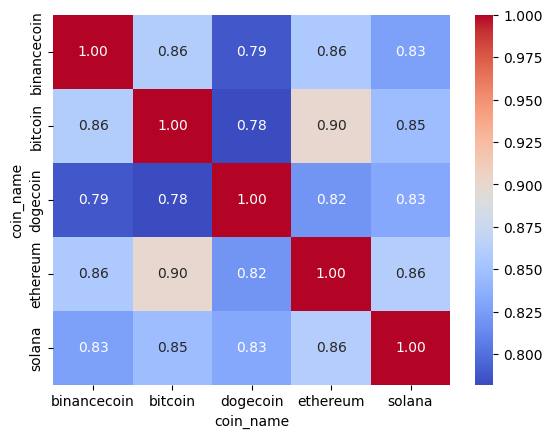

In [ ]:
corr_matrix = df_log_return.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

📊 Nilai korelasi: 0.78 – 0.90

👉 Artinya:

Semua aset punya hubungan kuat
Tapi tidak identik

🥇 A. Bitcoin – Ethereum (0.90)
- paling tinggi

💡 Insight:

Ethereum sangat mengikuti pergerakan Bitcoin sebagai market leader.

🐶 B. Dogecoin (paling rendah ~0.78)
- paling “berbeda”

💡 Insight:

Dogecoin lebih dipengaruhi faktor spekulatif dibanding fundamental pasar.

🔗 C. Semua tinggi (≥ 0.75)

💡 Insight:

Diversifikasi antar crypto kurang efektif karena sebagian besar aset bergerak searah.

In [ ]:
# Cumulative Return (Normalisasi)

df_cum_return = df_hourly.copy()

for col in df_cum_return.columns:
    first_valid = df_cum_return[col].dropna().iloc[0]
    df_cum_return[col] = (df_cum_return[col] / first_valid - 1) * 100

print("\n=== CUMULATIVE RETURN ===")
print(df_cum_return.head())


=== CUMULATIVE RETURN ===
coin_name            binancecoin   bitcoin  dogecoin  ethereum    solana
timestamp                                                               
2026-01-15 08:00:00     0.000000       NaN  0.000000       NaN  0.000000
2026-01-15 09:00:00     0.378450  0.000000  0.045957  0.000000 -0.117954
2026-01-15 10:00:00     0.361878  0.400270  0.460558  0.834666  0.499189
2026-01-15 11:00:00     0.038327  0.200808 -0.013255  0.843830  0.348084
2026-01-15 12:00:00    -0.085897 -0.074034 -0.276239  0.414722 -0.070500


B. Cumulative Return (untuk visualisasi performa)

👉 Rumus:((𝑃𝑡/𝑃0)−1)×100

Kenapa dipakai?
- Menyamakan semua koin ke titik awal yang sama (0%)
- Memudahkan perbandingan performa

💡 Insight:

Cumulative return digunakan untuk melihat pertumbuhan nilai aset dari titik awal sehingga performa antar aset dapat dibandingkan secara langsung.

🧠 A. Kenapa ada 0?

Contoh:

08:00 → BNB, DOGE, SOL = 0

👉 Karena:

itu adalah nilai pertama koin tersebut


rumus:𝑃/𝑃𝑎𝑤𝑎𝑙=1→𝑟𝑒𝑡𝑢𝑟𝑛=0%

❓ B. Kenapa ada NaN?

Contoh:

08:00 → BTC, ETH = NaN

👉 Karena:

di timestamp itu belum ada data untuk koin tersebut
jadi:𝑁𝑎𝑁/𝑃𝑎𝑤𝑎𝑙=𝑁𝑎𝑁

🕐 C. Kenapa padahal data ada dari jam 07?

👉 Ini kuncinya:

karna:

resample('1h')

➡️ waktu dibulatkan jadi:

07:00
08:00
09:00

Perbedaan timestamp asli dengan hasil resampling menyebabkan beberapa aset tidak memiliki nilai pada awal periode, sehingga menghasilkan nilai NaN, sementara aset yang memiliki nilai awal akan bernilai 0%

Resampling tidak salah, karena tujuannya adalah menyelaraskan timestamp antar aset. Nilai NaN muncul karena tidak semua aset memiliki data pada setiap interval waktu setelah proses agregasi. Hal ini merupakan karakteristik umum dalam time series yang berasal dari sumber data dengan frekuensi yang berbeda.

In [ ]:
df_plot = df_cum_return.fillna(0)

### Perbandingan Performa 90 Hari (Line Chart)

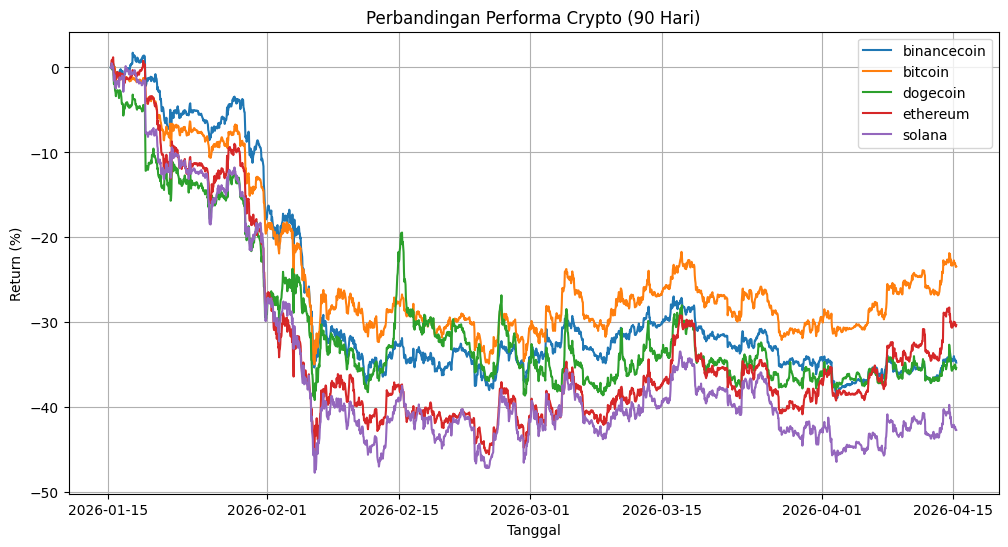

In [ ]:
plt.figure(figsize=(12,6))

for col in df_cum_return.columns:
    plt.plot(df_cum_return.index, df_cum_return[col], label=col)

plt.legend()
plt.title("Perbandingan Performa Crypto (90 Hari)")
plt.xlabel("Tanggal")
plt.ylabel("Return (%)")
plt.grid(True)

plt.show()

A. Tren umum
- Semua koin mengalami penurunan signifikan (~ -20% sampai -45%)

Menunjukkan:

pasar crypto sedang dalam kondisi bearish

⚖️ B. Bitcoin (paling stabil)
- Penurunan tidak sedalam yang lain
- Pergerakan lebih smooth

💡 Insight:

Bitcoin cenderung menjadi aset paling stabil dan sering dijadikan acuan pergerakan pasar.

⚡ C. Solana & Ethereum (paling volatile)
- Turun paling dalam (~ -40% sampai -45%)
- Fluktuasi besar

💡 Insight:

Altcoin seperti Solana dan Ethereum memiliki volatilitas lebih tinggi sehingga berisiko namun juga berpotensi memberikan return lebih besar.

🐶 D. Dogecoin (fluktuatif & tidak stabil arah)
- Naik turun tajam
- Tidak konsisten

💡 Insight:

Dogecoin menunjukkan karakter spekulatif dengan pergerakan yang tidak selalu mengikuti pola pasar utama.

🔗 E. Pergerakan cenderung bareng
- Semua turun di waktu yang sama

💡 Insight:

Pergerakan crypto dipengaruhi oleh sentimen pasar global yang sama.

Berdasarkan analisis, seluruh aset crypto menunjukkan korelasi yang tinggi yang menandakan pergerakan yang dipengaruhi oleh sentimen pasar yang sama. Bitcoin cenderung lebih stabil, sementara altcoin seperti Ethereum dan Solana memiliki volatilitas yang lebih tinggi. Selain itu, proses preprocessing seperti resampling dan normalisasi sangat penting untuk memastikan analisis time series yang valid.

📊 Analisis Karakteristik Big Data (5V)

Dalam proyek analisis cryptocurrency ini, data yang digunakan telah memenuhi sebagian besar karakteristik Big Data yang dikenal dengan konsep 5V, yaitu Volume, Velocity, Variety, Veracity, dan Value.

Pertama, dari aspek Volume (jumlah data), dataset yang digunakan terdiri dari 10.839 baris data yang mencakup lima jenis cryptocurrency selama periode 90 hari. Jumlah ini tergolong cukup besar untuk analisis time series dan memungkinkan pengamatan pola pergerakan harga secara lebih komprehensif.

Kedua, dari aspek Velocity (kecepatan data), data diperoleh melalui API CoinGecko dengan frekuensi yang relatif tinggi, yaitu per jam. Hal ini mencerminkan karakteristik data cryptocurrency yang bersifat dinamis dan berubah dengan cepat, sehingga termasuk dalam kategori high-frequency data.

Ketiga, dari aspek Variety (keberagaman data), dataset memiliki beberapa variabel penting seperti price, market cap, volume, dan coin name. Selain itu, data juga mencakup beberapa jenis aset cryptocurrency seperti Bitcoin, Ethereum, Solana, Dogecoin, dan Binance Coin. Hal ini menunjukkan adanya variasi baik dari sisi fitur maupun objek yang dianalisis.

Keempat, dari aspek Veracity (kualitas data), data telah melalui proses preprocessing yang meliputi pembersihan data (cleaning), penanganan missing value (NaN), resampling untuk penyelarasan waktu, serta alignment antar aset. Proses ini dilakukan untuk memastikan bahwa data yang digunakan dalam analisis memiliki kualitas yang baik dan dapat menghasilkan output yang valid.

Kelima, dari aspek Value (nilai atau insight), analisis yang dilakukan berhasil menghasilkan informasi yang bermakna. Berdasarkan grafik performa, seluruh cryptocurrency menunjukkan tren penurunan yang mengindikasikan kondisi pasar bearish. Selain itu, hasil analisis korelasi menunjukkan bahwa seluruh aset memiliki hubungan yang kuat (nilai korelasi antara 0,78 hingga 0,90), yang berarti pergerakan harga antar cryptocurrency cenderung saling mengikuti. Namun demikian, terdapat perbedaan tingkat volatilitas, di mana Bitcoin cenderung lebih stabil dibandingkan altcoin seperti Ethereum dan Solana yang menunjukkan fluktuasi lebih tinggi.

Secara keseluruhan, proyek ini telah memenuhi sebagian besar karakteristik Big Data, terutama pada aspek Value, karena mampu menghasilkan insight yang relevan dan dapat digunakan untuk memahami dinamika pasar cryptocurrency.